Different topolgies of graphs

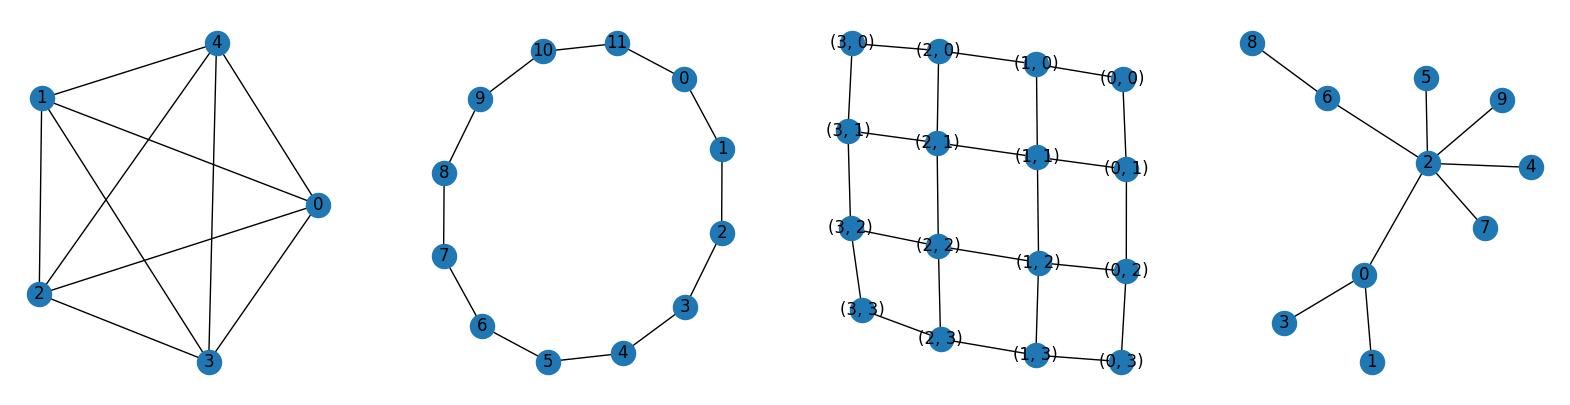

In [480]:
import networkx as nx
import matplotlib.pyplot as plt

# generate graphs
k5 = nx.complete_graph(5)
cycle = nx.cycle_graph(12)
grid = nx.grid_2d_graph(4, 4)
barb = nx.barabasi_albert_graph(10, 1)

# store in list
graphs = [k5, cycle, grid, barb]

# subplot so all graphs can be displayed
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# loop through list of graphs and draw
for ax, G in zip(axes, graphs):
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, ax=ax, with_labels=True)

plt.show()

In [470]:
# enter graph for experiment
selected_graph = grid

# input number of colours for the topology
num_colours = 5 if selected_graph == k5 else 2
palette = ["green", "purple", "orange", "red", "blue"]

''' 
simple conflict counting function
reads node colours and returns count of edges with same colour at eaxh end
'''
def count_conflicts(selected_graph, colouring):
    conflicts = 0
    for u, v in selected_graph.edges():
        if colouring[u] == colouring[v]:
            conflicts += 1
    return conflicts

'''
record of conficting nodes
store node pairs that are coflicting in the 'conflicting' set
'''
def conflicting_nodes(selected_graph, colouring):
    conflicting = set()
    for u, v in selected_graph.edges():
        if colouring[u] == colouring[v]:
            conflicting.add(u)
            conflicting.add(v)
    return conflicting

In [471]:
import random

max_steps = 200
num_runs = 20
stagnation_limit = 25      # trigger perturbation if no improvement for this many steps
perturb_fraction = 0.15    # fraction of nodes to recolour when stuck

# choose the colour that give the lowest total conflicts
# if there is a tie, pick one at random to avoid repeating the same pattern
def best_colour_with_random_tie_break(graph, colouring, node):
    current_conflicts = count_conflicts(graph, colouring)
    best_conflicts = current_conflicts
    best_colours = [colouring[node]]

    for c in range(num_colours):
        colouring[node] = c
        new_conflicts = count_conflicts(graph, colouring)

        if new_conflicts < best_conflicts:
            best_conflicts = new_conflicts
            best_colours = [c]
        elif new_conflicts == best_conflicts and c not in best_colours:
            best_colours.append(c)

    chosen = random.choice(best_colours)
    colouring[node] = chosen
    return best_conflicts

# recolours a small subset of nodes and keeps the search running
def perturb_colouring(selected_graph, colouring):
    nodes = list(selected_graph.nodes())
    num_changes = max(1, int(len(nodes) * perturb_fraction))
    selected = random.sample(nodes, num_changes)

    for node in selected:
        colouring[node] = random.randint(0, num_colours - 1)

# run one local search experiment and return colouring and the conflict history
def run_experiment(selected_graph):
    # start from a random colouring
    colouring = {node: random.randint(0, num_colours - 1) for node in selected_graph.nodes()}
    conflicts_over_time = [count_conflicts(selected_graph, colouring)]

    steps_without_improvement = 0

    for i in range(max_steps):
        current_conflicts = conflicts_over_time[-1]

        # stop if valid colouring is found
        if current_conflicts == 0:
            break

        bad_nodes = list(conflicting_nodes(selected_graph, colouring))

        #if no conflicting nodes, stop
        if not bad_nodes:
            break

        # update one of the conflicting node 
        node = random.choice(bad_nodes)
        previous_conflicts = current_conflicts
        new_conflicts = best_colour_with_random_tie_break(selected_graph, colouring, node)

        conflicts_over_time.append(new_conflicts)

        # track if we improved this step
        if new_conflicts < previous_conflicts:
            steps_without_improvement = 0
        else:
            steps_without_improvement += 1

        # if stuck for too long, apply small perturbation
        if steps_without_improvement >= stagnation_limit:
            perturb_colouring(selected_graph, colouring)
            conflicts_over_time.append(count_conflicts(selected_graph, colouring))
            steps_without_improvement = 0

    return colouring, conflicts_over_time



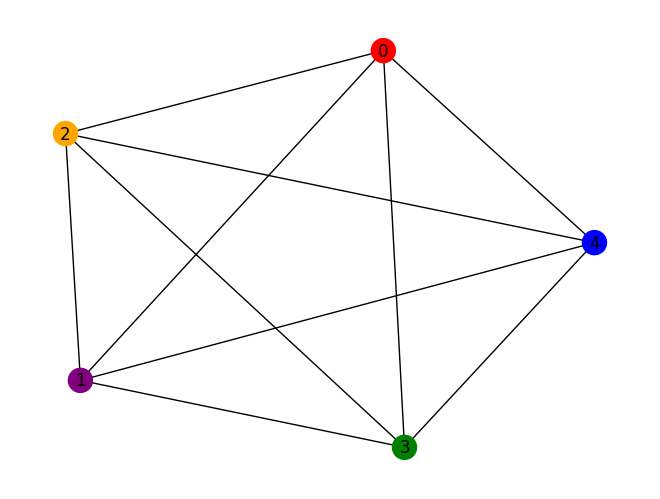

Successes: 20 / 20
Final conflicts: 0


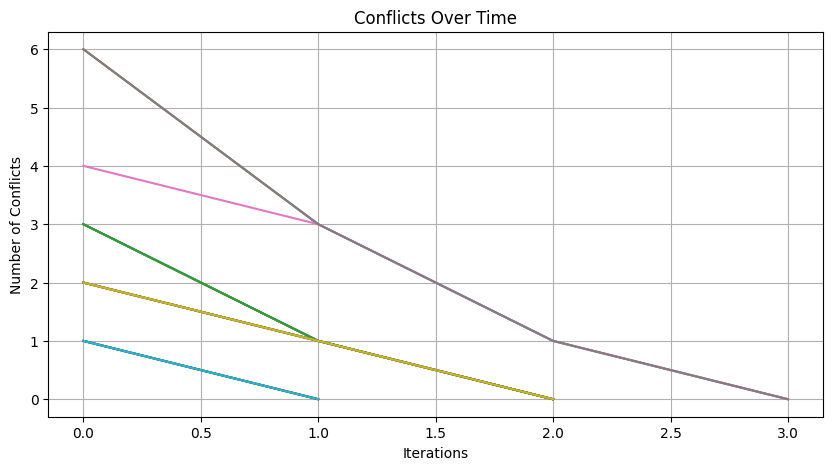

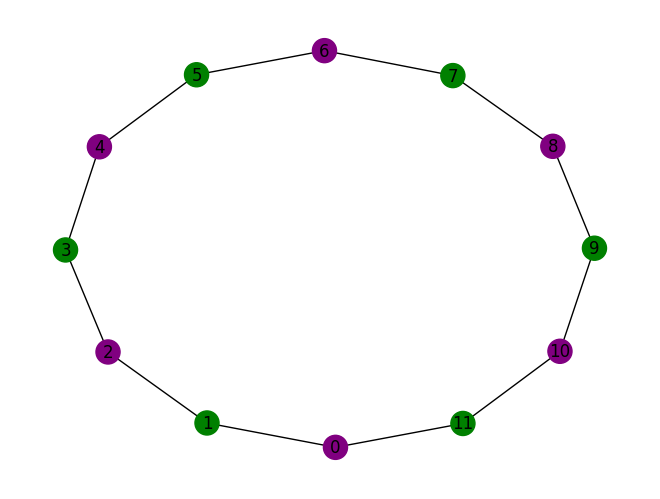

Successes: 20 / 20
Final conflicts: 0


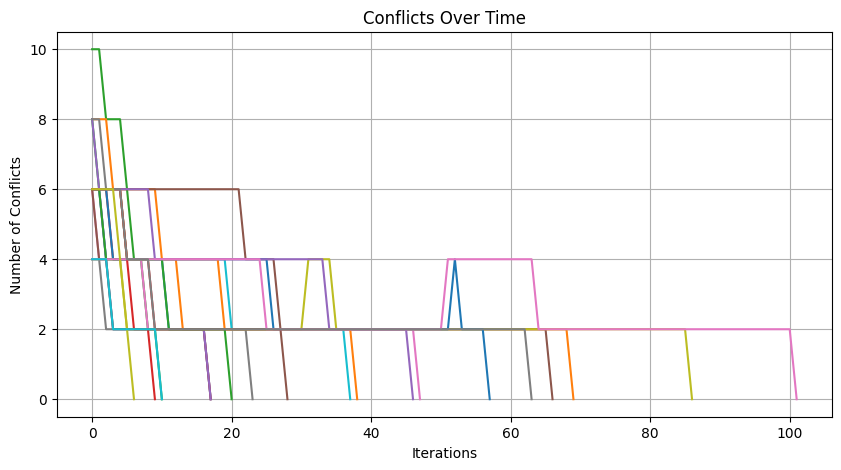

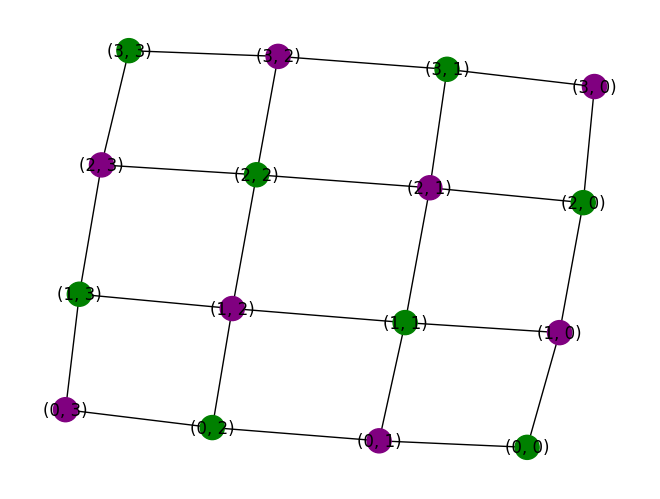

Successes: 19 / 20
Final conflicts: 0


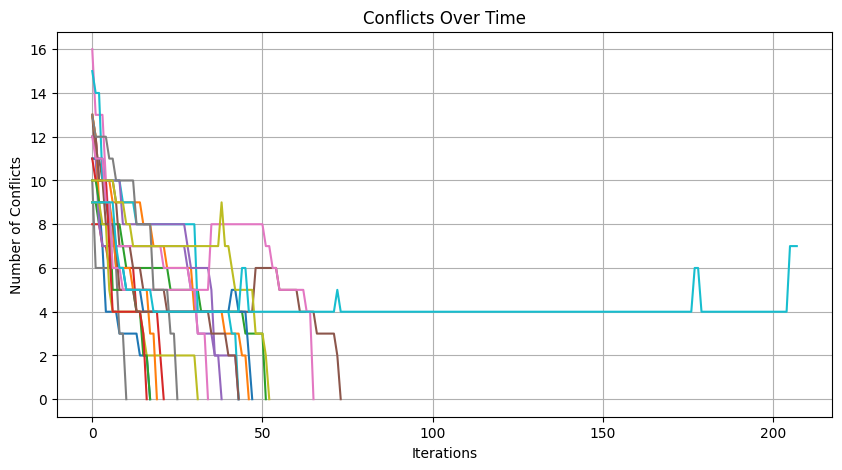

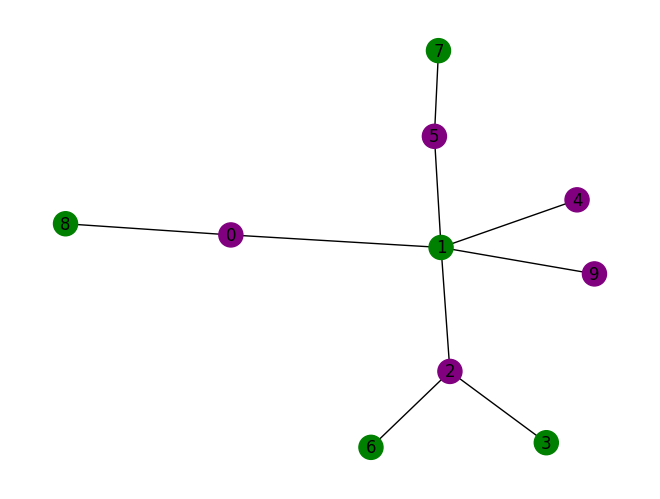

Successes: 16 / 20
Final conflicts: 0


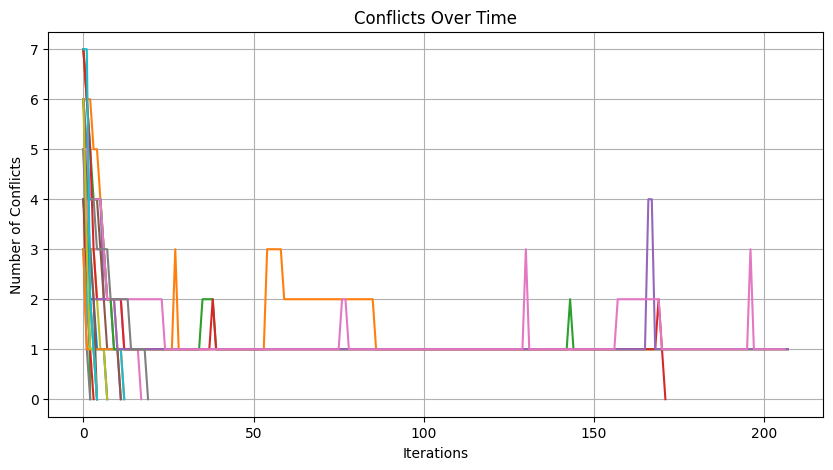

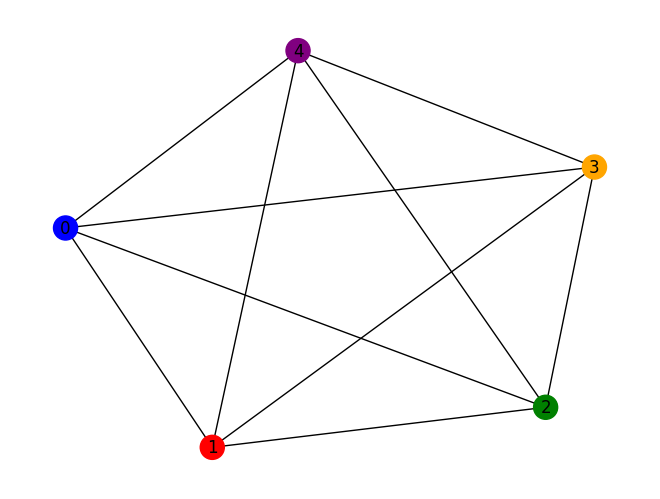

Successes: 20 / 20
Final conflicts: 0


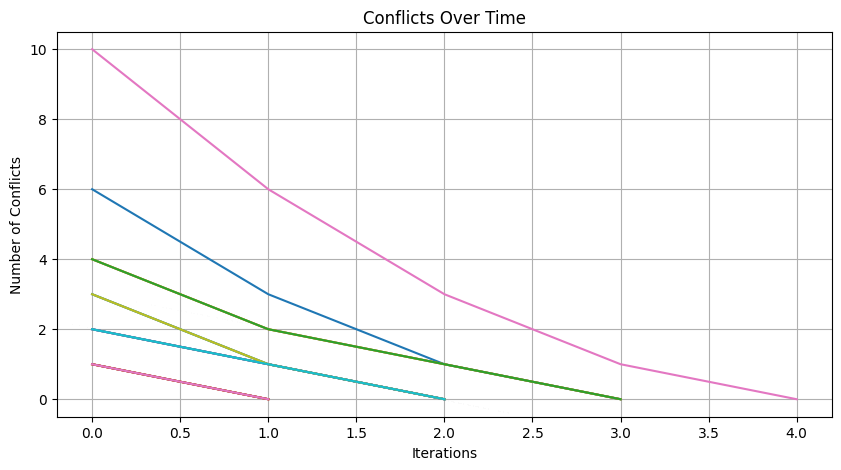

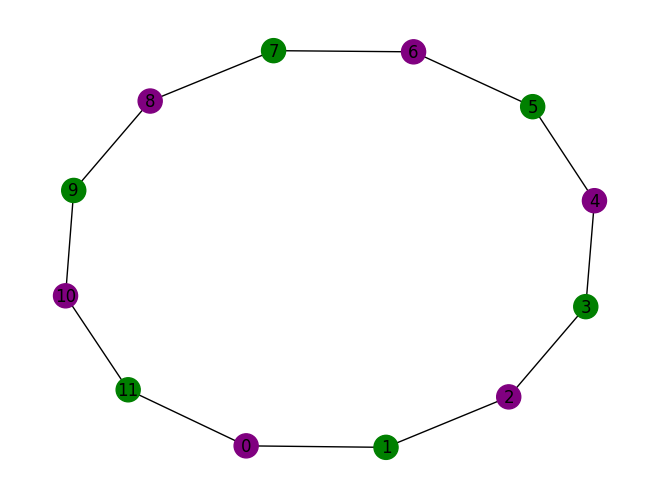

Successes: 20 / 20
Final conflicts: 0


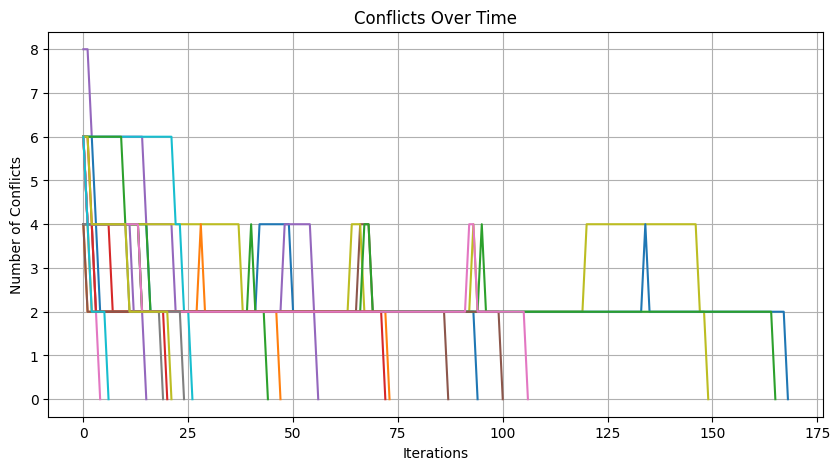

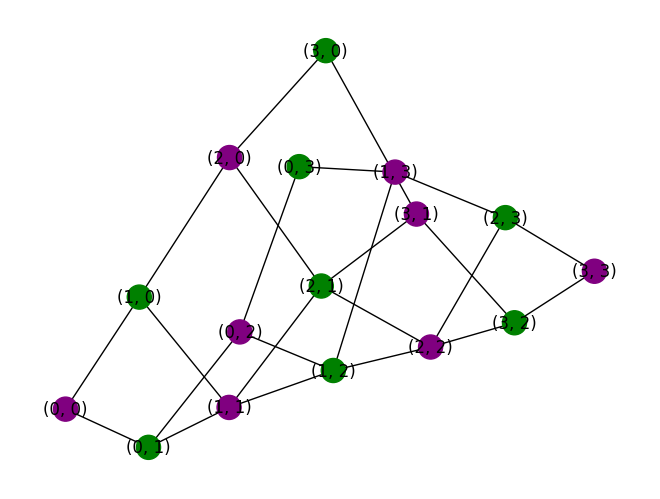

Successes: 20 / 20
Final conflicts: 0


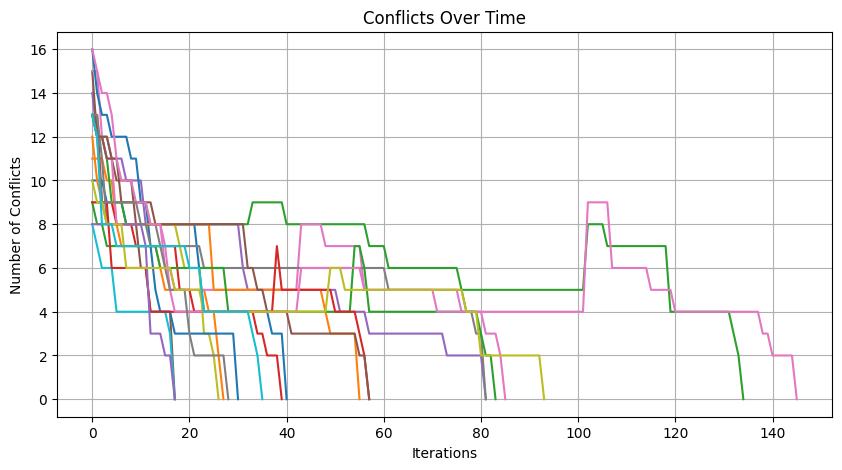

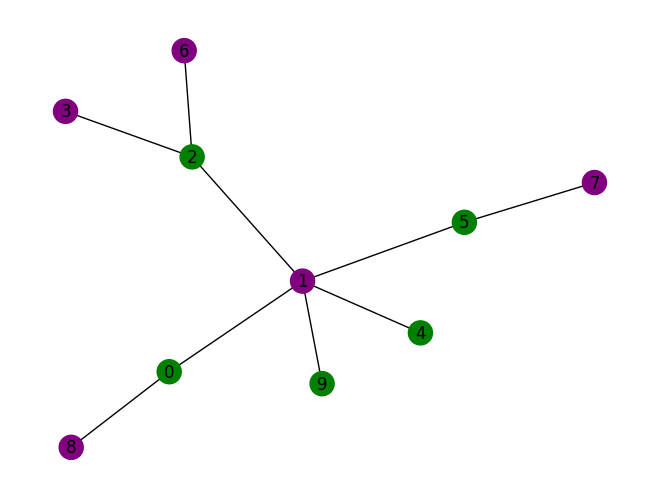

Successes: 16 / 20
Final conflicts: 0


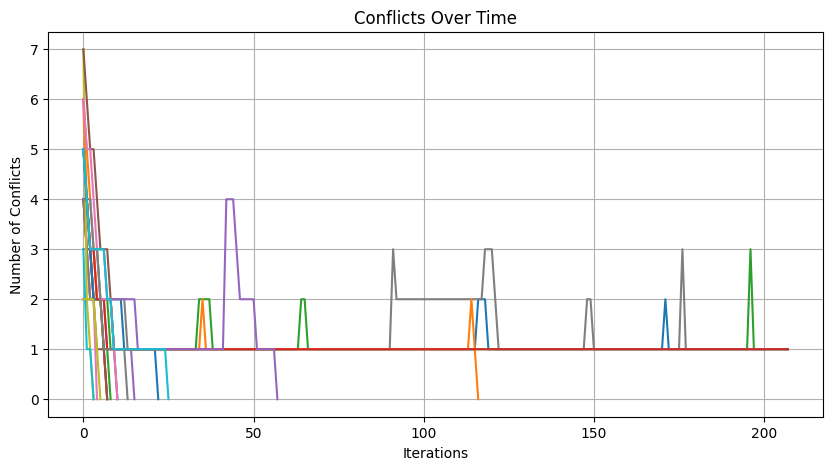

Total Rate of success over full experiment: 0.9437


In [477]:
   
r = 1
total_success_rate = 0
loop_count = 0

for r in range(1,3):
     # loop through the graphs for easier comparison
    for selected_graph in graphs:
        if selected_graph is k5:
            num_colours = 5
        else:
            num_colours = 2


        all_conflicts = []
        end_conflicts = []
        steps_to_solution = []
        solutions = []

        for i in range(num_runs):
            colouring, conflicts_over_time = run_experiment(selected_graph)
            all_conflicts.append(conflicts_over_time)
            end_conflicts.append(conflicts_over_time[-1])
            steps_to_solution.append(len(conflicts_over_time) - 1)
            solutions.append(colouring)

        successes = sum(1 for c in end_conflicts if c == 0)

        # choose a solved run if one exists, otherwise choose the best run
        if successes > 0:
            index = next(i for i, conflicts in enumerate(end_conflicts) if conflicts == 0)
        else:
            index = min(range(len(end_conflicts)), key=lambda i: end_conflicts[i])

        # store solution
        sample_colouring = solutions[index]

        # convert colour indices to colour names for plotting
        node_colours_plot = [
            palette[sample_colouring[n]]
            for n in selected_graph.nodes()
        ]

        # plot graph
        nx.draw(selected_graph, with_labels=True, node_color=node_colours_plot)
        plt.show()
        print("Successes:", successes, "/", num_runs)
        print("Final conflicts:", end_conflicts[index])

        # keep an accumulative score of algo success rate across all graph runs
        total_success_rate += (successes / (num_runs))

        # plot conflict over time for runs
        plt.figure(figsize=(10, 5))
        for conflicts in all_conflicts:
            plt.plot(conflicts)

        plt.title("Conflicts Over Time")
        plt.xlabel("Iterations")
        plt.ylabel("Number of Conflicts")
        plt.grid(True)
        plt.show()

        
        loop_count += 1

# print algorithms overall performance over full experiment
overall_sr = total_success_rate / (loop_count)
#print("Total success Rate:", total_success_rate, "Loop Count:", loop_count)
print(f"Total Rate of success over full experiment:", str(round(overall_sr,4)))
